C:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3333 - loss: 1.5977 - val_accuracy: 0.0000e+00 - val_loss: 1.5963
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6667 - loss: 1.5192 - val_accuracy: 0.0000e+00 - val_loss: 1.6566
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.8333 - loss: 1.5072 - val_accuracy: 0.0000e+00 - val_loss: 1.7136
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.6667 - loss: 1.4319 - val_accuracy: 0.0000e+00 - val_loss: 1.7775
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 1.0000 - loss: 1.4220 - val_accuracy: 0.0000e+00 - val_loss: 1.8433
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 1.0000 - loss: 1.3341 - val_accuracy: 0.0000e+00 - val_loss: 1.9115
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 1.0000 - loss: 1.2648 - val_accuracy: 0.0000e+00 - val_loss: 1.9879
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 1.0000 - loss: 1.2326 - val_accu

C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


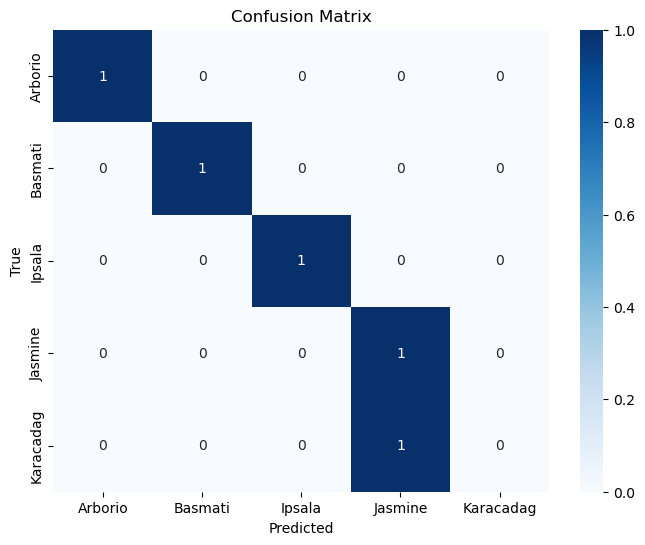

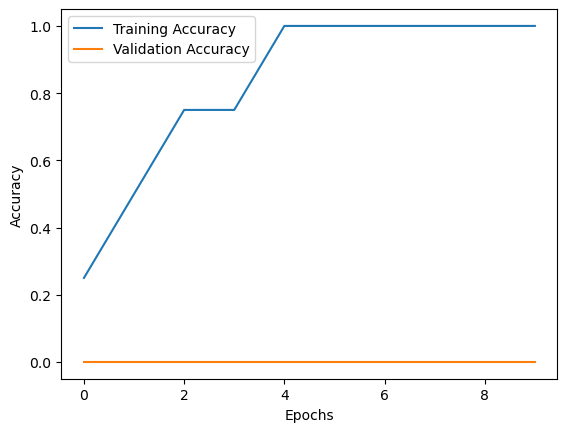

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Grain Length (mm)': [6.2, 5.9, 6.1, 6.5, 5.8],
    'Grain Width (mm)': [2.1, 2.0, 2.2, 2.3, 1.9],
    'Grain Shape': ['Long', 'Long', 'Round', 'Long', 'Irregular'],
    'Grain Color': ['White', 'Brown', 'Golden', 'White', 'Brown'],
    'Defect Type': ['None', 'Broken', 'Discolored', 'Foreign', 'None'],
    'Moisture Content (%)': [12, 11, 10, 13, 14],
    'Starch Content (%)': [75, 70, 78, 72, 80],
    'Protein Content (%)': [7, 6, 8, 7, 7],
    'Aroma': ['Mild', 'Mild', 'Strong', 'Strong', 'Mild'],
    'Texture': ['Soft', 'Firm', 'Soft', 'Firm', 'Rough'],
    'Taste': ['Sweet', 'Bitter', 'Neutral', 'Sweet', 'Neutral']
}
df = pd.DataFrame(data)
# Step 2: Encode categorical columns
encoder = LabelEncoder()
categorical_cols = ['Grain Shape', 'Grain Color', 'Defect Type', 'Aroma', 'Texture', 'Taste', 'Rice Name']
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])
# Step 3: Prepare features (X) and labels (y)
X = df.drop('Rice Name', axis=1)  # Features
y = df['Rice Name']  # Target variable
# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Step 5: One-hot encode the target variable
y_encoded = to_categorical(y)
# Step 6: Reshape the data for 2D CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
# Step 7: Build the 2D CNN model
model = Sequential()
model.add(Reshape((X_reshaped.shape[1], 1, 1), input_shape=(X_reshaped.shape[1], 1)))
model.add(Conv2D(32, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Conv2D(64, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_encoded.shape[1], activation='softmax'))
# Step 8: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Step 9: Train the model
history = model.fit(X_reshaped, y_encoded, epochs=10, batch_size=2, validation_split=0.2)
# Step 10: Evaluate the model
loss, accuracy = model.evaluate(X_reshaped, y_encoded)
print(f'Model Loss: {loss}')
print(f'Model Accuracy: {accuracy}')
# Step 11: Predict and calculate metrics
y_pred = np.argmax(model.predict(X_reshaped), axis=1)
y_true = np.argmax(y_encoded, axis=1)
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))
# Step 12: Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# Step 13: Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


C:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3333 - loss: 1.6089 - val_accuracy: 0.0000e+00 - val_loss: 1.6095
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 0.5000 - loss: 1.5382 - val_accuracy: 0.0000e+00 - val_loss: 1.6346
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.5000 - loss: 1.5141 - val_accuracy: 0.0000e+00 - val_loss: 1.6512
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.8333 - loss: 1.4442 - val_accuracy: 0.0000e+00 - val_loss: 1.6702
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.6667 - loss: 1.4405 - val_accuracy: 0.0000e+00 - val_loss: 1.6924
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 409ms/step - accuracy: 1.0000 - loss: 1.3563 - val_accuracy: 0.0000e+00 - val_loss: 1.7157
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 1.0000 - loss: 1.3067 - val_accuracy: 0.0000e+00 - val_loss: 1.7474
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 488ms/step - accuracy: 1.0000 - loss: 1.3195 - val_acc

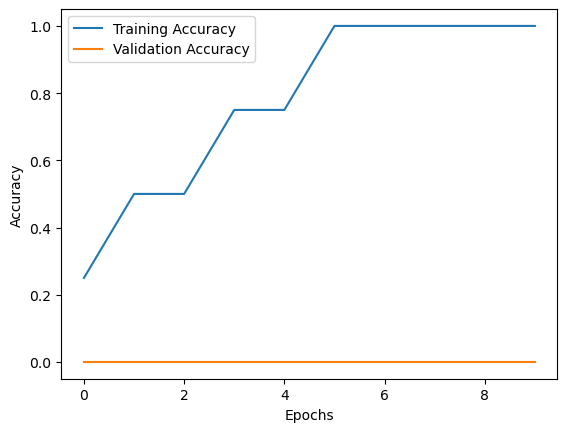

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
Predicted Classes: [1 3 0 2 3]


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
# Step 1: Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Grain Length (mm)': [6.2, 5.9, 6.1, 6.5, 5.8],
    'Grain Width (mm)': [2.1, 2.0, 2.2, 2.3, 1.9],
    'Grain Shape': ['Long', 'Long', 'Round', 'Long', 'Irregular'],
    'Grain Color': ['White', 'Brown', 'Golden', 'White', 'Brown'],
    'Defect Type': ['None', 'Broken', 'Discolored', 'Foreign', 'None'],
    'Moisture Content (%)': [12, 11, 10, 13, 14],
    'Starch Content (%)': [75, 70, 78, 72, 80],
    'Protein Content (%)': [7, 6, 8, 7, 7],
    'Aroma': ['Mild', 'Mild', 'Strong', 'Strong', 'Mild'],
    'Texture': ['Soft', 'Firm', 'Soft', 'Firm', 'Rough'],
    'Taste': ['Sweet', 'Bitter', 'Neutral', 'Sweet', 'Neutral']
}

df = pd.DataFrame(data)
# Step 2: Encode categorical columns
encoder = LabelEncoder()
df['Grain Shape'] = encoder.fit_transform(df['Grain Shape'])
df['Grain Color'] = encoder.fit_transform(df['Grain Color'])
df['Defect Type'] = encoder.fit_transform(df['Defect Type'])
df['Aroma'] = encoder.fit_transform(df['Aroma'])
df['Texture'] = encoder.fit_transform(df['Texture'])
df['Taste'] = encoder.fit_transform(df['Taste'])
df['Rice Name'] = encoder.fit_transform(df['Rice Name'])  # Encoding the target variable
# Step 3: Prepare features (X) and labels (Y)
X = df.drop('Rice Name', axis=1)  # Features
y = df['Rice Name']  # Target variable (Rice Name)
# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Step 5: One-hot encode the target variable
y_encoded = to_categorical(y)
# Step 6: Reshape the data to make it suitable for a 2D CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
# Step 7: Build the 2D CNN model
model = Sequential()

# Add a 2D convolutional layer
model.add(Reshape((X_reshaped.shape[1], 1, 1), input_shape=(X_reshaped.shape[1], 1)))
model.add(Conv2D(32, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
# Add more convolutional layers
model.add(Conv2D(64, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
# Flatten the output for the dense layer
model.add(Flatten())
# Fully connected layer
model.add(Dense(128, activation='relu'))
# Output layer
model.add(Dense(y_encoded.shape[1], activation='softmax'))  # Multi-class classification
# Step 8: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Step 9: Train the model
history = model.fit(X_reshaped, y_encoded, epochs=10, batch_size=2, validation_split=0.2)
# Step 10: Evaluate the model
loss, accuracy = model.evaluate(X_reshaped, y_encoded)
print(f'Model Loss: {loss}')
print(f'Model Accuracy: {accuracy}')
# Step 11: Plot training history (accuracy)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
# Step 12: Make predictions (Optional)
predictions = model.predict(X_reshaped)
predicted_class = np.argmax(predictions, axis=1)
print(f'Predicted Classes: {predicted_class}')


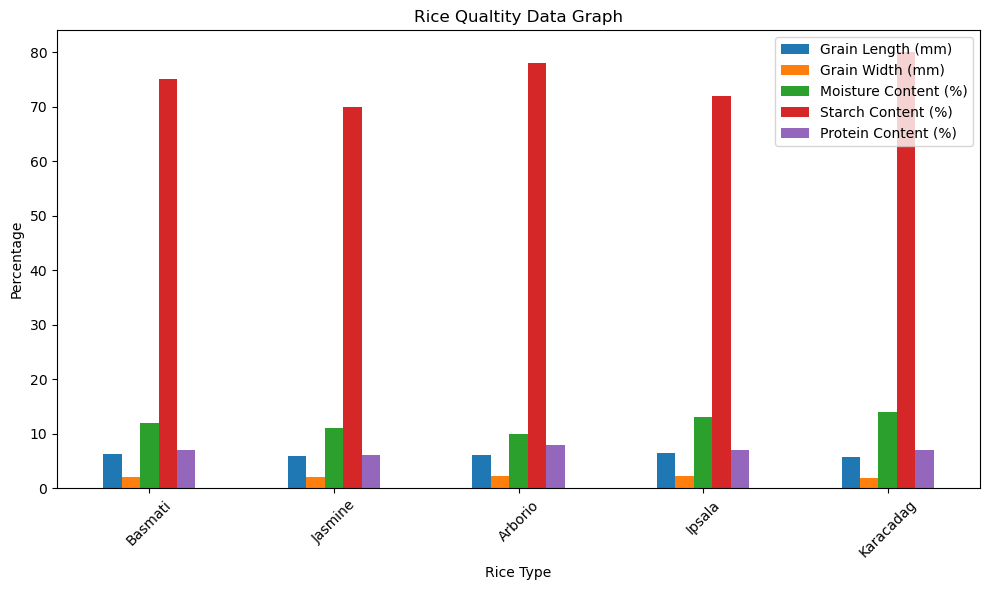

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
# Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Grain Length (mm)': [6.2, 5.9, 6.1, 6.5, 5.8],
    'Grain Width (mm)': [2.1, 2.0, 2.2, 2.3, 1.9],
    'Moisture Content (%)': [12, 11, 10, 13, 14],
    'Starch Content (%)': [75, 70, 78, 72, 80],
    'Protein Content (%)': [7, 6, 8, 7, 7],
}
# Convert the data to a pandas DataFrame
df = pd.DataFrame(data)
# Set the rice names as the index
df.set_index('Rice Name', inplace=True)
# Plot a bar chart
df.plot(kind='bar', figsize=(10,6))
# Set labels and title
plt.title('Rice Qualtity Data Graph')
plt.xlabel('Rice Type')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.tight_layout()
# Display the plot
plt.show()



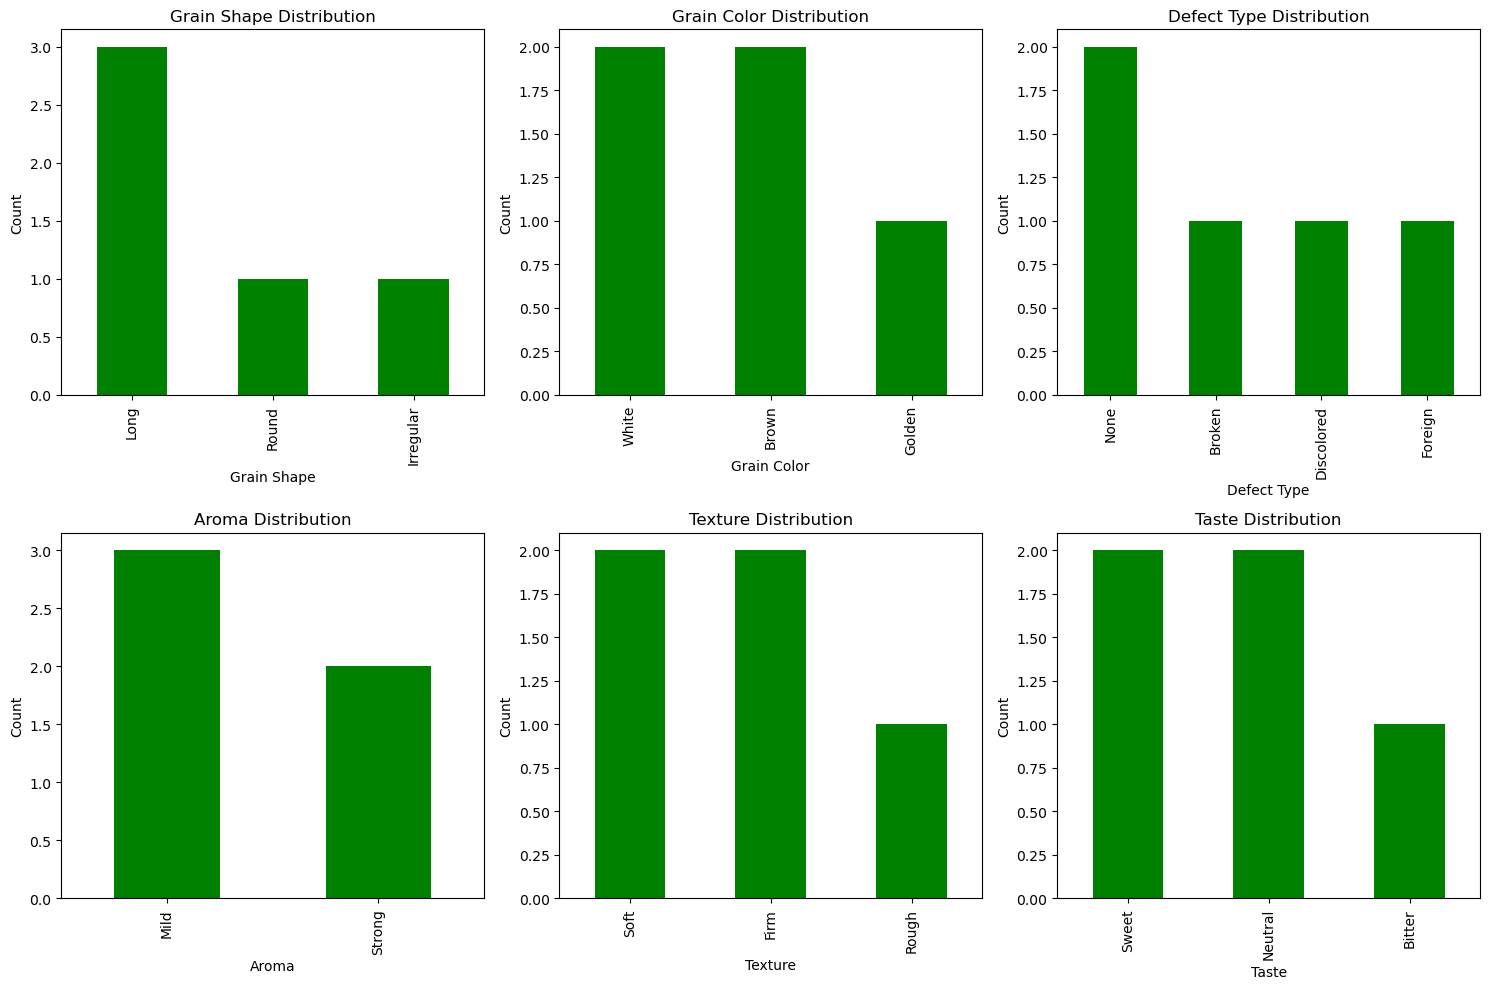

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
# Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Grain Shape': ['Long', 'Long', 'Round', 'Long', 'Irregular'],
    'Grain Color': ['White', 'Brown', 'Golden', 'White', 'Brown'],
    'Defect Type': ['None', 'Broken', 'Discolored', 'Foreign', 'None'],
    'Aroma': ['Mild', 'Mild', 'Strong', 'Strong', 'Mild'],
    'Texture': ['Soft', 'Firm', 'Soft', 'Firm', 'Rough'],
    'Taste': ['Sweet', 'Bitter', 'Neutral', 'Sweet', 'Neutral'],
}
# Convert the data to a pandas DataFrame
df = pd.DataFrame(data)
# Set the rice names as the index
df.set_index('Rice Name', inplace=True)
# Create bar charts for categorical data
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
# List of categorical columns
categorical_columns = ['Grain Shape', 'Grain Color', 'Defect Type', 'Aroma', 'Texture', 'Taste']
# Iterate through each categorical column and plot a bar chart
for i, col in enumerate(categorical_columns):
    row, col_idx = divmod(i, 3)
    ax = axs[row, col_idx]
    df[col].value_counts().plot(kind='bar', ax=ax, color='Green')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


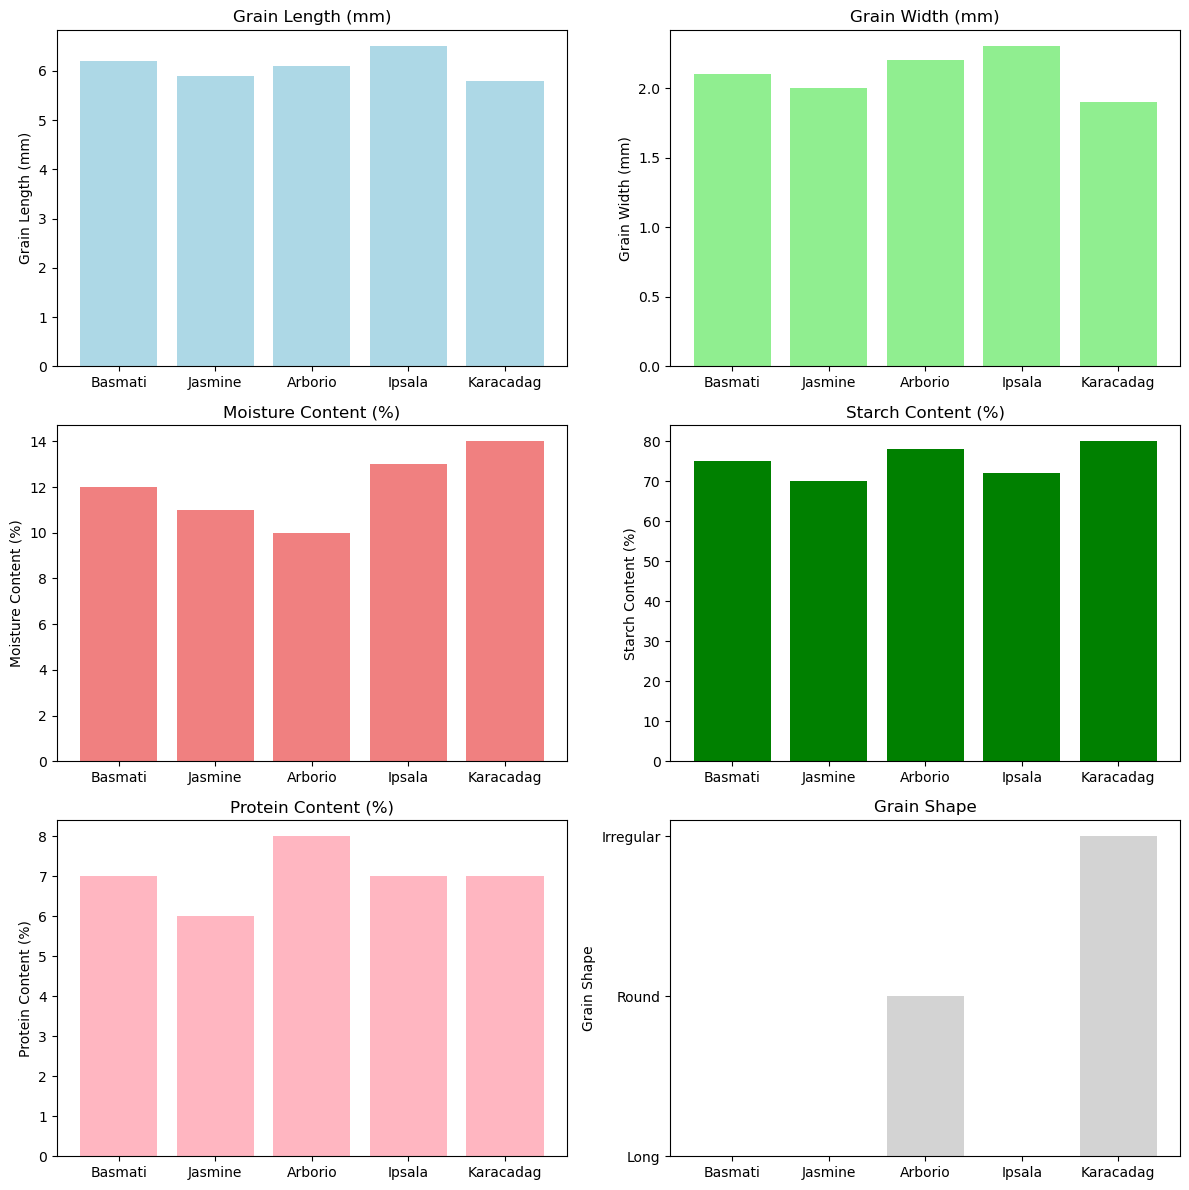

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
# Data for the rice dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Grain Length (mm)': [6.2, 5.9, 6.1, 6.5, 5.8],
    'Grain Width (mm)': [2.1, 2.0, 2.2, 2.3, 1.9],
    'Moisture Content (%)': [12, 11, 10, 13, 14],
    'Starch Content (%)': [75, 70, 78, 72, 80],
    'Protein Content (%)': [7, 6, 8, 7, 7],
    'Grain Shape': ['Long', 'Long', 'Round', 'Long', 'Irregular'],
    'Grain Color': ['White', 'Brown', 'Golden', 'White', 'Brown'],
    'Defect Type': ['None', 'Broken', 'Discolored', 'Foreign', 'None'],
    'Aroma': ['Mild', 'Mild', 'Strong', 'Strong', 'Mild'],
    'Texture': ['Soft', 'Firm', 'Soft', 'Firm', 'Rough'],
    'Taste': ['Sweet', 'Bitter', 'Neutral', 'Sweet', 'Neutral']
}

# Convert to DataFrame for easier plotting
df = pd.DataFrame(data)
# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# Bar Chart for Grain Length
axes[0, 0].bar(df['Rice Name'], df['Grain Length (mm)'], color='lightblue')
axes[0, 0].set_title('Grain Length (mm)')
axes[0, 0].set_ylabel('Grain Length (mm)')
# Bar Chart for Grain Width
axes[0, 1].bar(df['Rice Name'], df['Grain Width (mm)'], color='lightgreen')
axes[0, 1].set_title('Grain Width (mm)')
axes[0, 1].set_ylabel('Grain Width (mm)')
# Bar Chart for Moisture Content
axes[1, 0].bar(df['Rice Name'], df['Moisture Content (%)'], color='lightcoral')
axes[1, 0].set_title('Moisture Content (%)')
axes[1, 0].set_ylabel('Moisture Content (%)')
# Bar Chart for Starch Content
axes[1, 1].bar(df['Rice Name'], df['Starch Content (%)'], color='green')
axes[1, 1].set_title('Starch Content (%)')
axes[1, 1].set_ylabel('Starch Content (%)')
# Bar Chart for Protein Content
axes[2, 0].bar(df['Rice Name'], df['Protein Content (%)'], color='lightpink')
axes[2, 0].set_title('Protein Content (%)')
axes[2, 0].set_ylabel('Protein Content (%)')
# Bar Chart for Grain Shape
axes[2, 1].bar(df['Rice Name'], df['Grain Shape'], color='lightgray')
axes[2, 1].set_title('Grain Shape')
axes[2, 1].set_ylabel('Grain Shape')
# Layout adjustments
plt.tight_layout()
plt.show()



C:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.0000e+00 - loss: 1.6155 - val_accuracy: 0.0000e+00 - val_loss: 1.6215
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - accuracy: 0.3333 - loss: 1.5663 - val_accuracy: 0.0000e+00 - val_loss: 1.6620
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.1667 - loss: 1.5514 - val_accuracy: 0.0000e+00 - val_loss: 1.7004
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.3333 - loss: 1.5222 - val_accuracy: 0.0000e+00 - val_loss: 1.7414
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6667 - loss: 1.4958 - val_accuracy: 0.0000e+00 - val_loss: 1.7858
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - accuracy: 0.6667 - loss: 1.4540 - val_accuracy: 0.0000e+00 - val_loss: 1.8332
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.8333 - loss: 1.4432 - val_accuracy: 0.0000e+00 - val_loss: 1.8818
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.8333 - loss: 1.3898 - val_

C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


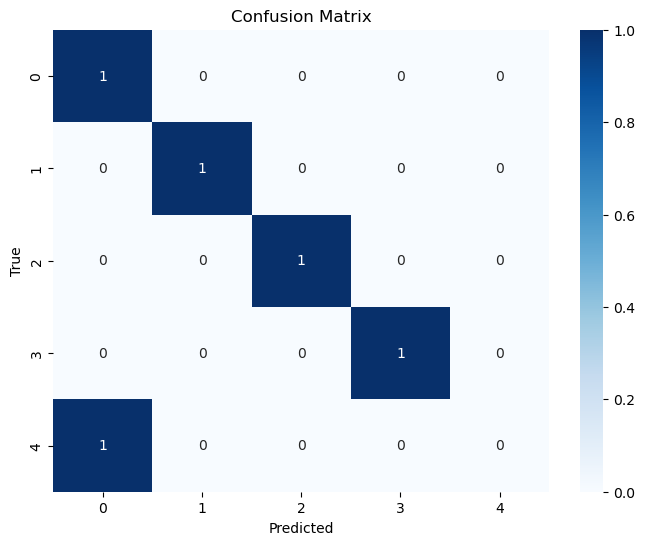

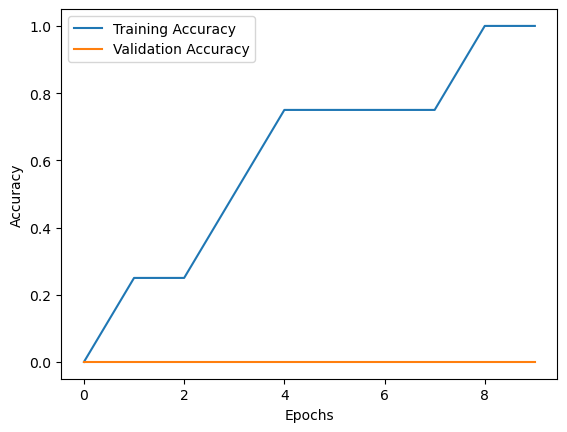

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Temperature (°C)': [25, 20, 22, 24, 30],
    'Humidity (%)': [60, 55, 65, 50, 70],
    'Airflow (m³/h)': [5, 3, 4, 6, 2],
    'Light Exposure (hrs)': [2, 0, 1, 3, 4],
    'Storage Container': ['Airtight Bin', 'Plastic Bag', 'Airtight Bin', 'Plastic Bag', 'Airtight Bin'],
    'Storage Type': ['Bulk', 'Individual', 'Bulk', 'Individual', 'Bulk'],
    'Shelf Life (Months)': [12, 9, 10, 8, 6]
}
df = pd.DataFrame(data)
# Step 2: Encode categorical columns
encoder = LabelEncoder()
categorical_cols = ['Storage Container', 'Storage Type', 'Rice Name']
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])
# Step 3: Prepare features (X) and labels (y)
X = df.drop('Rice Name', axis=1)  # Features
y = df['Rice Name']  # Target variable
# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Step 5: One-hot encode the target variable
y_encoded = to_categorical(y)
# Step 6: Reshape the data for 2D CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
# Step 7: Build the 2D CNN model
model = Sequential()
model.add(Reshape((X_reshaped.shape[1], 1, 1), input_shape=(X_reshaped.shape[1], 1)))
model.add(Conv2D(32, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Conv2D(64, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_encoded.shape[1], activation='softmax'))
# Step 8: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Step 9: Train the model
history = model.fit(X_reshaped, y_encoded, epochs=10, batch_size=2, validation_split=0.2)
# Step 10: Evaluate the model
loss, accuracy = model.evaluate(X_reshaped, y_encoded)
print(f'Model Loss: {loss}')
print(f'Model Accuracy: {accuracy}')
# Step 11: Predict and calculate metrics
y_pred = np.argmax(model.predict(X_reshaped), axis=1)
y_true = np.argmax(y_encoded, axis=1)
print("Classification Report:")
print(classification_report(y_true, y_pred))
# Step 12: Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# Step 13: Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


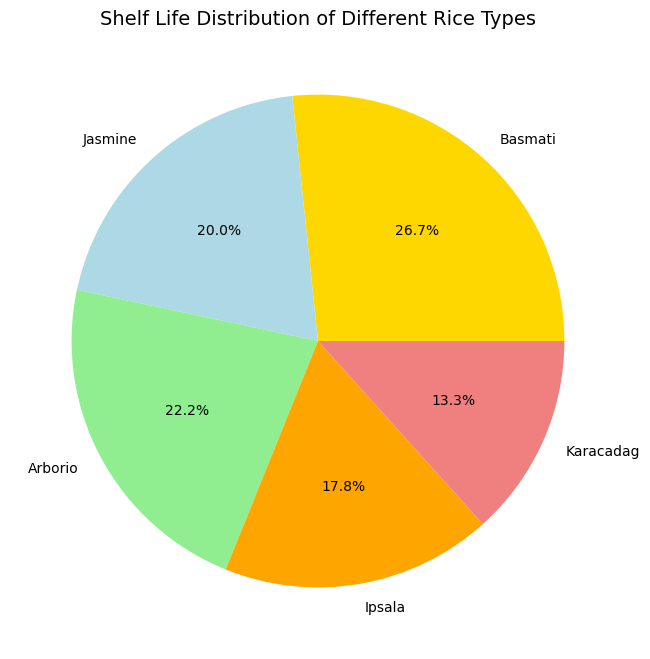

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
# Data for rice shelf life and storage conditions
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Temperature (°C)': [25, 20, 22, 24, 30],
    'Humidity (%)': [60, 55, 65, 50, 70],
    'Airflow (m³/h)': [5, 3, 4, 6, 2],
    'Light Exposure (hrs)': [2, 0, 1, 3, 4],
    'Shelf Life (Months)': [12, 9, 10, 8, 6]
}
# Convert the data into a pandas DataFrame
df = pd.DataFrame(data)
# Plotting a pie chart for Shelf Life based on Rice Name
plt.figure(figsize=(8, 8))
plt.pie(df['Shelf Life (Months)'], labels=df['Rice Name'], autopct='%1.1f%%', colors=['gold', 'lightblue', 'lightgreen', 'orange', 'lightcoral'])
# Adding a title
plt.title('Shelf Life Distribution of Different Rice Types', fontsize=14)
# Display the plot
plt.show()


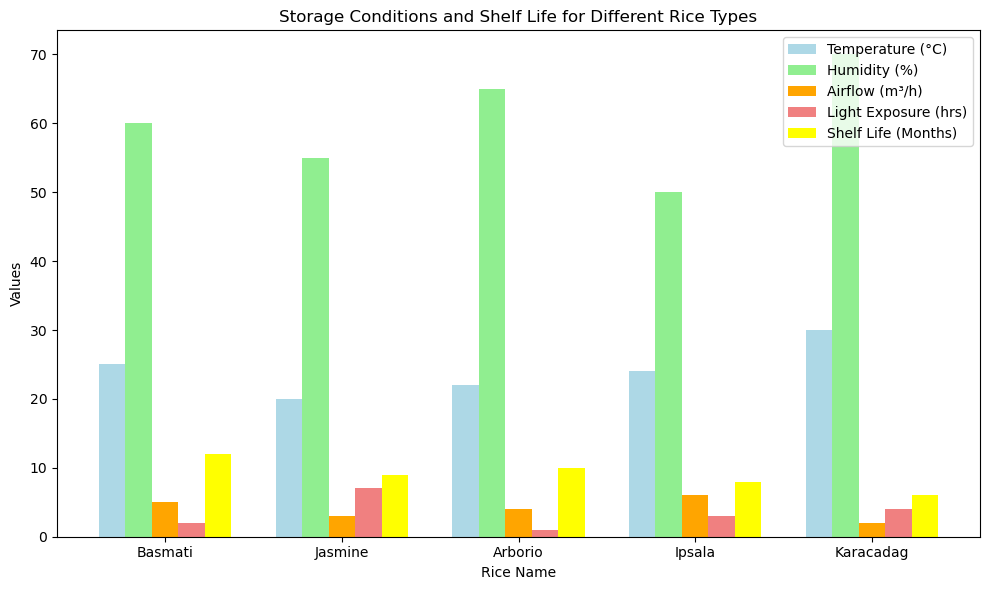

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Data for rice shelf life and storage conditions
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Temperature (°C)': [25, 20, 22, 24, 30],
    'Humidity (%)': [60, 55, 65, 50, 70],
    'Airflow (m³/h)': [5, 3, 4, 6, 2],
    'Light Exposure (hrs)': [2, 7, 1, 3, 4],
    'Shelf Life (Months)': [12, 9, 10, 8, 6]
}
# Convert the data into a pandas DataFrame
df = pd.DataFrame(data)
# Create the bar charts for each variable
bar_width = 0.15
x = np.arange(len(df['Rice Name']))
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 2 * bar_width, df['Temperature (°C)'], bar_width, label='Temperature (°C)', color='lightblue')
ax.bar(x - bar_width, df['Humidity (%)'], bar_width, label='Humidity (%)', color='lightgreen')
ax.bar(x, df['Airflow (m³/h)'], bar_width, label='Airflow (m³/h)', color='orange')
ax.bar(x + bar_width, df['Light Exposure (hrs)'], bar_width, label='Light Exposure (hrs)', color='lightcoral')
ax.bar(x + 2 * bar_width, df['Shelf Life (Months)'], bar_width, label='Shelf Life (Months)', color='yellow')
# Customize the plot
ax.set_xlabel('Rice Name')
ax.set_ylabel('Values')
ax.set_title('Storage Conditions and Shelf Life for Different Rice Types')
ax.set_xticks(x)
ax.set_xticklabels(df['Rice Name'])
ax.legend()
# Show the plot
plt.tight_layout()
plt.show()


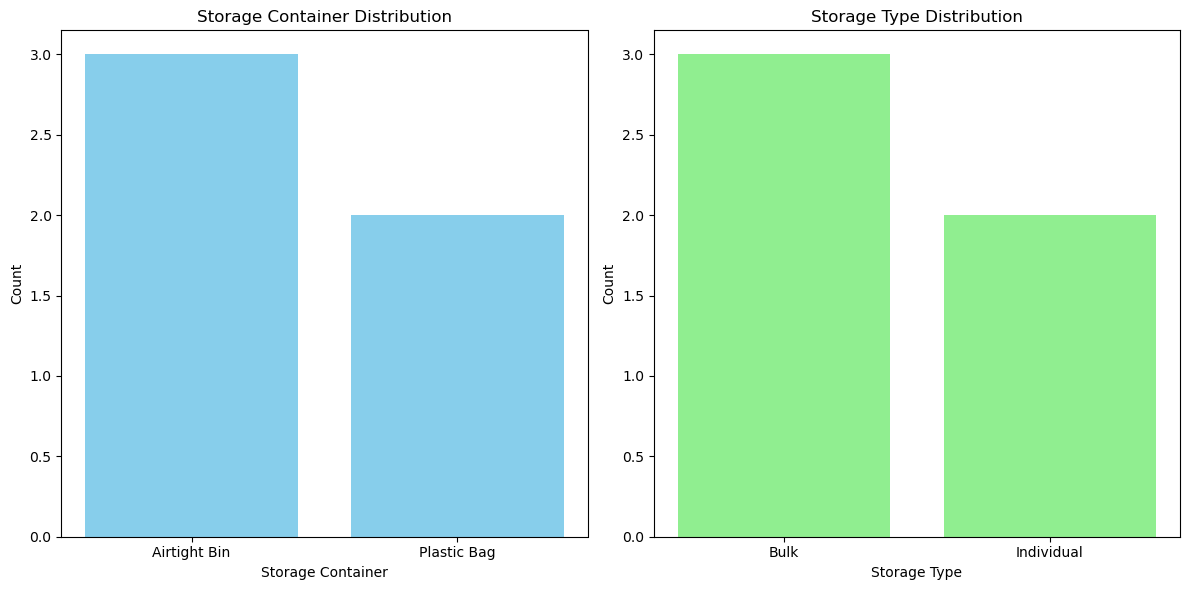

In [11]:
import matplotlib.pyplot as plt
# Data for storage container and type
storage_data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Storage Container': ['Airtight Bin', 'Plastic Bag', 'Airtight Bin', 'Plastic Bag', 'Airtight Bin'],
    'Storage Type': ['Bulk', 'Individual', 'Bulk', 'Individual', 'Bulk']
}
# Convert to DataFrame for easier plotting
df = pd.DataFrame(storage_data)
# Count occurrences of different storage types and containers
storage_container_count = df['Storage Container'].value_counts()
storage_type_count = df['Storage Type'].value_counts()
# Plotting bar charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Bar chart for Storage Container
ax1.bar(storage_container_count.index, storage_container_count.values, color='skyblue')
ax1.set_title('Storage Container Distribution')
ax1.set_xlabel('Storage Container')
ax1.set_ylabel('Count')
# Bar chart for Storage Type
ax2.bar(storage_type_count.index, storage_type_count.values, color='lightgreen')
ax2.set_title('Storage Type Distribution')
ax2.set_xlabel('Storage Type')
ax2.set_ylabel('Count')
# Show the plots
plt.tight_layout()
plt.show()


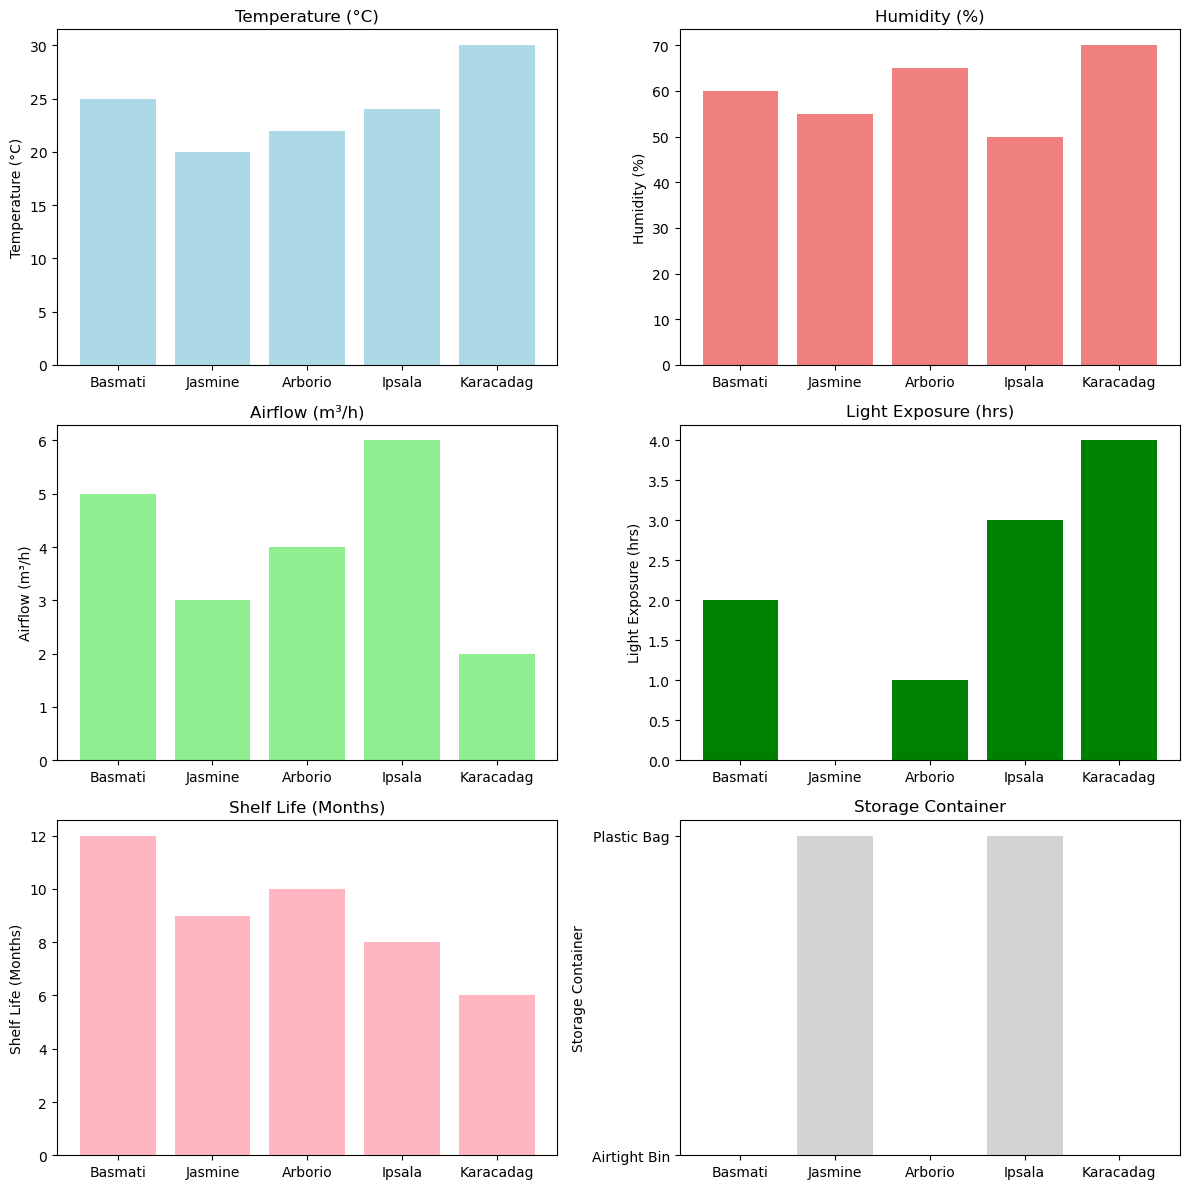

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
# Data for the rice dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Temperature (°C)': [25, 20, 22, 24, 30],
    'Humidity (%)': [60, 55, 65, 50, 70],
    'Airflow (m³/h)': [5, 3, 4, 6, 2],
    'Light Exposure (hrs)': [2, 0, 1, 3, 4],
    'Shelf Life (Months)': [12, 9, 10, 8, 6],
    'Storage Container': ['Airtight Bin', 'Plastic Bag', 'Airtight Bin', 'Plastic Bag', 'Airtight Bin'],
    'Storage Type': ['Bulk', 'Individual', 'Bulk', 'Individual', 'Bulk']
}
# Convert to DataFrame for easier plotting
df = pd.DataFrame(data)
# Create a figure with subplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
# Bar Chart for Temperature
axes[0, 0].bar(df['Rice Name'], df['Temperature (°C)'], color='lightblue')
axes[0, 0].set_title('Temperature (°C)')
axes[0, 0].set_ylabel('Temperature (°C)')
# Bar Chart for Humidity
axes[0, 1].bar(df['Rice Name'], df['Humidity (%)'], color='lightcoral')
axes[0, 1].set_title('Humidity (%)')
axes[0, 1].set_ylabel('Humidity (%)')
# Bar Chart for Airflow
axes[1, 0].bar(df['Rice Name'], df['Airflow (m³/h)'], color='lightgreen')
axes[1, 0].set_title('Airflow (m³/h)')
axes[1, 0].set_ylabel('Airflow (m³/h)')
# Bar Chart for Light Exposure
axes[1, 1].bar(df['Rice Name'], df['Light Exposure (hrs)'], color='Green')
axes[1, 1].set_title('Light Exposure (hrs)')
axes[1, 1].set_ylabel('Light Exposure (hrs)')
# Bar Chart for Shelf Life
axes[2, 0].bar(df['Rice Name'], df['Shelf Life (Months)'], color='lightpink')
axes[2, 0].set_title('Shelf Life (Months)')
axes[2, 0].set_ylabel('Shelf Life (Months)')
# Bar Chart for Storage Container
axes[2, 1].bar(df['Rice Name'], df['Storage Container'], color='lightgray')
axes[2, 1].set_title('Storage Container')
axes[2, 1].set_ylabel('Storage Container')
# Layout adjustments
plt.tight_layout()
plt.show()



C:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.3333 - loss: 1.6101 - val_accuracy: 0.0000e+00 - val_loss: 1.7741
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.5000 - loss: 1.5743 - val_accuracy: 0.0000e+00 - val_loss: 1.8348
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.5000 - loss: 1.5485 - val_accuracy: 0.0000e+00 - val_loss: 1.8992
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3333 - loss: 1.5289 - val_accuracy: 0.0000e+00 - val_loss: 1.9591
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8333 - loss: 1.4588 - val_accuracy: 0.0000e+00 - val_loss: 2.0226
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8333 - loss: 1.4391 - val_accuracy: 0.0000e+00 - val_loss: 2.0850
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6667 - loss: 1.4379 - val_accuracy: 0.0000e+00 - val_loss: 2.1496
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6667 - loss: 1.3797 - val_accu

C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


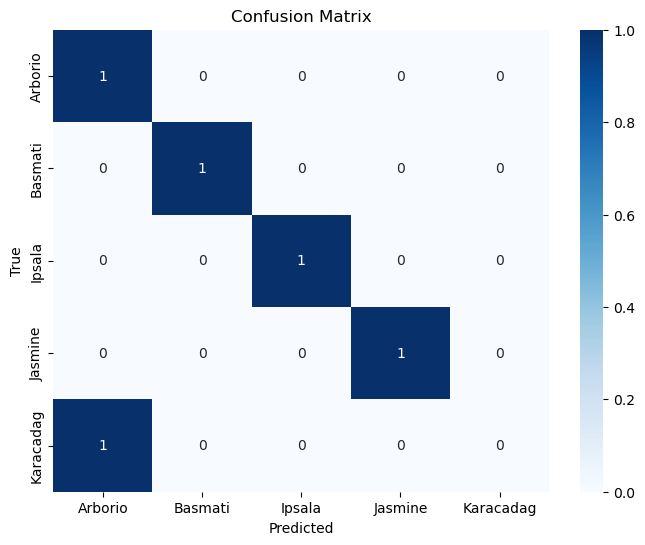

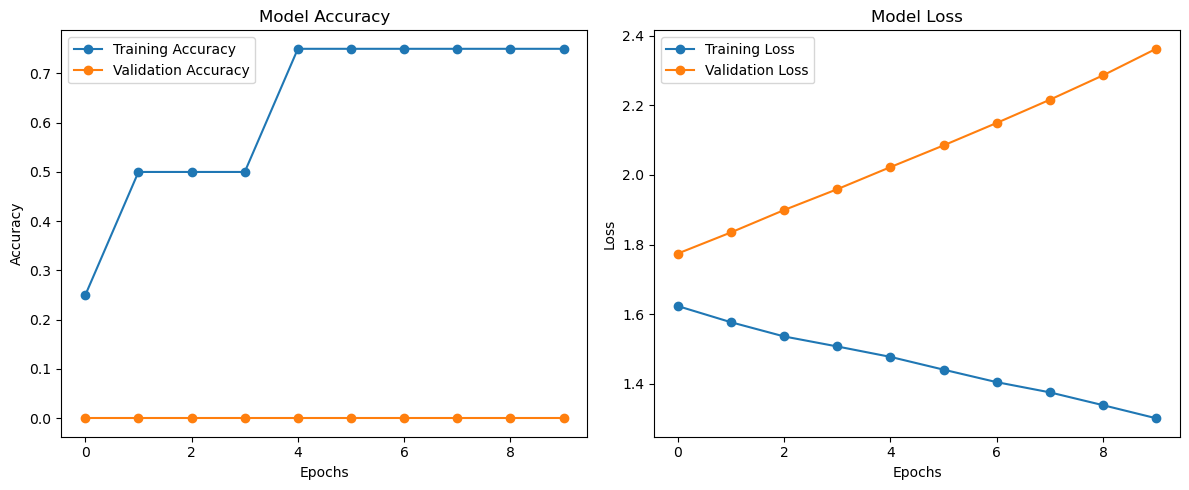

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Temperature (°C)': [25, 20, 22, 24, 30],
    'Humidity (%)': [60, 55, 65, 50, 70],
    'Airflow (m³/h)': [5, 3, 4, 6, 2],
    'Light Exposure (hrs)': [2, 0, 1, 3, 4],
    'Storage Container': ['Airtight Bin', 'Plastic Bag', 'Airtight Bin', 'Plastic Bag', 'Airtight Bin'],
    'Storage Type': ['Bulk', 'Individual', 'Bulk', 'Individual', 'Bulk'],
    'Shelf Life (Months)': [12, 9, 10, 8, 6]
}
df = pd.DataFrame(data)
# Step 2: Encode categorical columns
encoder = LabelEncoder()
categorical_cols = ['Storage Container', 'Storage Type', 'Rice Name']
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])
# Step 3: Prepare features (X) and labels (y)
X = df.drop('Rice Name', axis=1)  # Features
y = df['Rice Name']  # Target variable
# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Step 5: One-hot encode the target variable
y_encoded = to_categorical(y)
# Step 6: Reshape the data for 2D CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
# Step 7: Build the 2D CNN model
model = Sequential()
model.add(Reshape((X_reshaped.shape[1], 1, 1), input_shape=(X_reshaped.shape[1], 1)))
model.add(Conv2D(32, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Conv2D(64, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_encoded.shape[1], activation='softmax'))
# Step 8: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Step 9: Train the model
history = model.fit(X_reshaped, y_encoded, epochs=10, batch_size=2, validation_split=0.2)
# Step 10: Evaluate the model
loss, accuracy = model.evaluate(X_reshaped, y_encoded)
print(f'Model Loss: {loss}')
print(f'Model Accuracy: {accuracy}')
# Step 11: Predict and calculate metrics
y_pred = np.argmax(model.predict(X_reshaped), axis=1)
y_true = np.argmax(y_encoded, axis=1)
print("Classification Report:")
print(classification_report(y_true, y_pred))
# Step 12: Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# Step 13: Plot training history
plt.figure(figsize=(12, 5))
# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


C:\Anaconda\Lib\site-packages\keras\src\layers\reshaping\reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.0000e+00 - loss: 1.6127 - val_accuracy: 0.0000e+00 - val_loss: 1.5682
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.6667 - loss: 1.5386 - val_accuracy: 0.0000e+00 - val_loss: 1.6343
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8333 - loss: 1.4938 - val_accuracy: 0.0000e+00 - val_loss: 1.7009
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 1.0000 - loss: 1.4497 - val_accuracy: 0.0000e+00 - val_loss: 1.7697
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 1.0000 - loss: 1.4029 - val_accuracy: 0.0000e+00 - val_loss: 1.8381
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 1.0000 - loss: 1.3564 - val_accuracy: 0.0000e+00 - val_loss: 1.9113
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 1.0000 - loss: 1.3314 - val_accuracy: 0.0000e+00 - val_loss: 1.9902
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 1.2799 - val_

C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


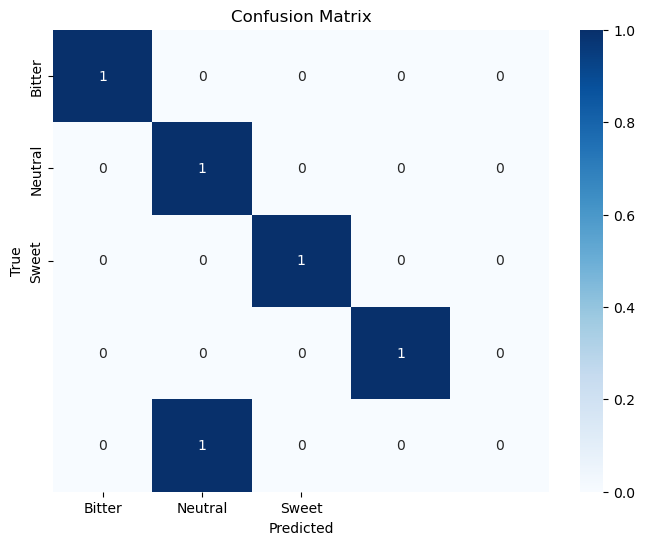

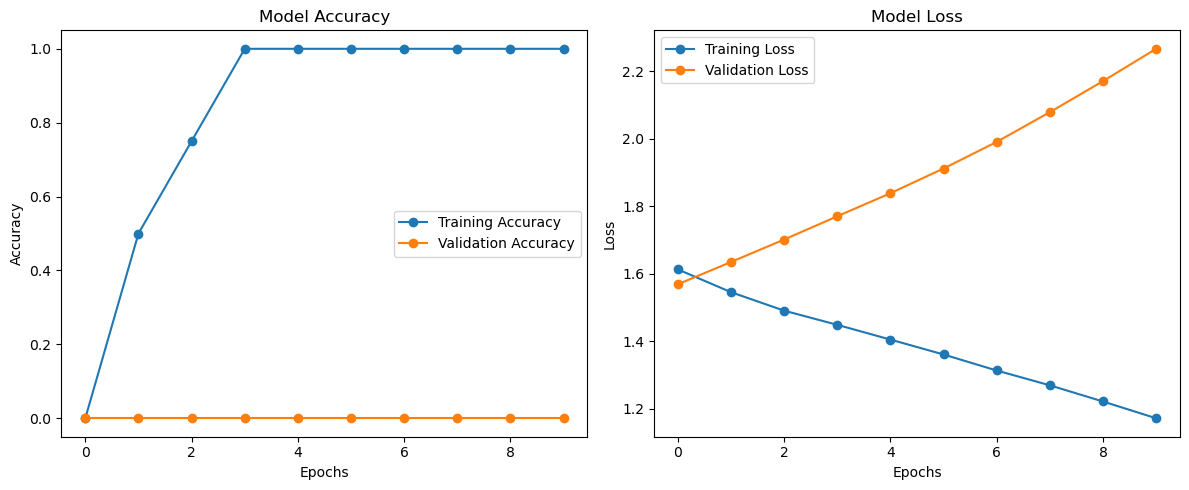

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Reshape
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
# Step 1: Create the dataset
data = {
    'Rice Name': ['Basmati', 'Jasmine', 'Arborio', 'Ipsala', 'Karacadag'],
    'Grain Length (mm)': [6.2, 5.9, 6.1, 6.5, 5.8],
    'Grain Width (mm)': [2.1, 2.0, 2.2, 2.3, 1.9],
    'Grain Shape': ['Long', 'Long', 'Round', 'Long', 'Irregular'],
    'Grain Color': ['White', 'Brown', 'Golden', 'White', 'Brown'],
    'Defect Type': ['None', 'Broken', 'Discolored', 'Foreign', 'None'],
    'Moisture Content (%)': [12, 11, 10, 13, 14],
    'Starch Content (%)': [75, 70, 78, 72, 80],
    'Protein Content (%)': [7, 6, 8, 7, 7],
    'Aroma': ['Mild', 'Mild', 'Strong', 'Strong', 'Mild'],
    'Texture': ['Soft', 'Firm', 'Soft', 'Firm', 'Rough'],
    'Taste': ['Sweet', 'Bitter', 'Neutral', 'Sweet', 'Neutral']
}
df = pd.DataFrame(data)
# Step 2: Encode categorical columns
encoder = LabelEncoder()
categorical_cols = ['Rice Name', 'Grain Shape', 'Grain Color', 'Defect Type', 'Aroma', 'Texture', 'Taste']
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])
# Step 3: Prepare features (X) and labels (y)
X = df.drop('Rice Name', axis=1)  # Features
y = df['Rice Name']  # Target variable
# Step 4: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Step 5: One-hot encode the target variable
y_encoded = to_categorical(y)
# Step 6: Reshape the data for 2D CNN
X_reshaped = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1], 1)
# Step 7: Build the 2D CNN model
model = Sequential()
model.add(Reshape((X_reshaped.shape[1], 1, 1), input_shape=(X_reshaped.shape[1], 1)))
model.add(Conv2D(32, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Conv2D(64, (2, 2), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(y_encoded.shape[1], activation='softmax'))
# Step 8: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Step 9: Train the model
history = model.fit(X_reshaped, y_encoded, epochs=10, batch_size=2, validation_split=0.2)
# Step 10: Evaluate the model
loss, accuracy = model.evaluate(X_reshaped, y_encoded)
print(f'Model Loss: {loss}')
print(f'Model Accuracy: {accuracy}')
# Step 11: Predict and calculate metrics
y_pred = np.argmax(model.predict(X_reshaped), axis=1)
y_true = np.argmax(y_encoded, axis=1)
print("Classification Report:")
print(classification_report(y_true, y_pred))
# Step 12: Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
# Step 13: Plot training history
plt.figure(figsize=(12, 5))
# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
